<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_10_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SECTION A: Conceptual Understanding

## 1. Why do we need autograd if we already know calculus and can compute derivatives manually?

- Ans: We need autograd because it automates the calculation of derivatives in a neural network. in calculus we have to calculate complex problems manually which can be very tough and time consuming when very large and complex situation arrives. Autograd reduce this hassle and automates the process of calculation.

## 2. What problem does autograd solve in deep neural networks with many layers?
- Ans: Autograd solves the problem of manually calculating gradients in deep networks with many layers. Since the loss depends on every weight through several layers, finding gradients by hand using the chain rule is slow and error-prone. Autograd automatically tracks all operations during the forward pass and then computes the exact gradients during backpropagation, saving time and avoiding mistakes. The optimizer then uses these gradients to update the weights and biases.

## 3. What is a computation graph? Explain it using a simple example like: y = (x^2 + 3x) * 2

- Ans: A computation graph breaks a math expression into small steps, connected like a flowchart. Each step is one simple operation (add, multiply, square).
  
  a = x²

  b = 3x

  c = a + b

  y = c * 2

  x → square → a ─┐
              ├→ add → c → multiply by 2 → y

  x → mult by 3 → b ─┘

  Forward pass (calculate y): plug in x, move left to right.

  x = 2 → a = 4, b = 6, c = 10, y = 20

  Backward pass (find dy/dx): move right to left, multiply small derivatives together (chain rule).

  dy/dx = 2 × (2x + 3) = 14 (at x = 2)


## 4. In a computation graph, what do nodes represent and what do edges represent?
- Ans:
  
  Nodes represent either an input/variable (like w, x, b) or an operation (like add, multiply, square).
  
  Edges represent the flow of data — they show which values go into an operation and where the result goes next.

  Simple example: z = w·x + b

  w ─┐
   ├→ [multiply] → [add] ← b
   
  x ─┘                    

                            │
                             ↓
                               z

  

## 5. Why is the computation graph called a Directed Acyclic Graph (DAG)?
- Ans:

    Directed → each edge has a direction — data flows one way, from inputs toward the output (never backward in the forward pass).
    
    Acyclic → there are no loops or cycles — you can't follow the edges and end up back where you started. Each operation depends only on earlier steps, never on itself or a later step.

    Simple example: z = w·x + b

    Data flows only forward (w, x, b → z), and there's no path that loops back — so it's a Directed Acyclic Graph.


## 6. What happens to gradient flow if the graph contains a cycle?
- Ans:
    
    If the graph had a cycle, gradient flow would break down:

    No valid order to compute things. Backpropagation relies on processing nodes in a clear order (topological order) — from output back to inputs. A cycle means there's no such order; some node would depend on a value that depends on itself.
    
    Infinite loop / undefined gradients. To get a node's gradient, you'd need the gradient of a node that (through the cycle) depends on itself. This creates infinite recursion — the chain rule can never "finish," so the gradient never resolves to a fixed value.
    
    Chain rule can't be applied cleanly. The chain rule assumes each variable's effect passes through a finite, traceable path to the output. A cycle breaks that assumption.


## 7. Explain in your own words how the chain rule is applied automatically in autograd.

- Ans:
       
    Autograd applies the chain rule automatically by tracking every operation during the forward pass to build a computation graph. Each operation has a known local derivative (e.g., multiplication, addition). During backpropagation, autograd moves backward through the graph and multiplies these local derivatives together, step by step — this is the chain rule being applied automatically. This gives the exact gradient of the loss with respect to every weight and bias, without us manually deriving the formula.

# SECTION B: Computation Graph and Chain Rule

## 8. Suppose:
              x = 2
              y = x^2
              z = 3*y
              L = z + 4
Draw the computation graph and manually compute dL/dx.

- Ans:

    Graph:

    X^2 ==> y ==> z ==> L

    dL/dz = in respect to z, the value is 1

    dz/dy = 3, because y is constant times y = 3 x 1 = 3

    dy/dx = 2x

    so, dl/dx = dl/dz x dz/dy x dy/dx = 1 x 3 x 2x = 1 x 3 x 2*2 = 12

## 9. If:
          y = sigmoid(w*x + b)
          L = (y - t)^2
Write the full chain rule expression for dL/dw before simplifying.

- Ans:


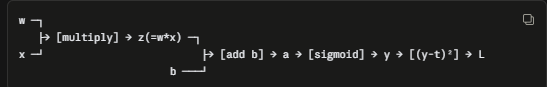

dl/dw = dl/dy x dy/da x da/dw

dl/dy = 2(y - t)

dy/da = sigmoid x (1 - sigmoid) x [x] ===> e.g. [ y (1-y) ]

da/dw = x

so, dl/dw = [2(y - t) * (sigmoid x (1 - sigmoid) x [x]) * x]

## 10. Why does Binary Cross Entropy with Sigmoid simplify to (y_pred - y)?

This is one of the more satisfying results in ML math — let me walk through the derivation.

**Setup**

Let $z$ be the raw logit (pre-sigmoid output), and:

$$\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}$$

The binary cross-entropy loss is:

$$L = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]$$

We want $\frac{\partial L}{\partial z}$ — the gradient with respect to the *logit*, not $\hat y$ directly. That's the key: the clean result only appears when you differentiate w.r.t. $z$, using the chain rule through the sigmoid.

**Step 1: Derivative of loss w.r.t. $\hat{y}$**

$$\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}$$

**Step 2: Derivative of sigmoid w.r.t. $z$**

The sigmoid has the well-known self-referential derivative:

$$\frac{\partial \hat{y}}{\partial z} = \sigma(z)(1-\sigma(z)) = \hat{y}(1-\hat{y})$$

**Step 3: Chain rule**

$$\frac{\partial L}{\partial z} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} = \left[-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right] \cdot \hat{y}(1-\hat{y})$$

Distribute the $\hat{y}(1-\hat{y})$ term into each part:

$$= -y(1-\hat{y}) + (1-y)\hat{y}$$

$$= -y + y\hat{y} + \hat{y} - y\hat{y}$$

$$= \hat{y} - y$$

**Result**

$$\frac{\partial L}{\partial z} = \hat{y} - y = y_{pred} - y$$

**Why this matters**

The messy $\frac{y}{\hat y}$ and $\frac{1-y}{1-\hat y}$ terms from the log-loss derivative are exactly canceled by the $\hat{y}(1-\hat{y})$ factor from the sigmoid's own derivative. That cancellation isn't a coincidence — cross-entropy and sigmoid are *designed* as a matched pair (cross-entropy is essentially the negative log-likelihood for a Bernoulli distribution, and sigmoid is the canonical link function for Bernoulli in the exponential family). The same clean cancellation happens with softmax + categorical cross-entropy for the same underlying reason.

Practically, this is why frameworks often provide a fused "sigmoid + BCE" loss (e.g., `BCEWithLogitsLoss` in PyTorch) — it lets you skip computing $\hat y$ explicitly and backprop this clean gradient directly, which is also more numerically stable.

## 11. What would change in the gradient flow if we used ReLU instead of Sigmoid?

Short answer: the clean cancellation breaks, and you'd likely get broken gradients or an undefined loss.

**Why:**

1. **No cancellation.** BCE's gradient trick relies on sigmoid's derivative being $\hat y(1-\hat y)$, which exactly cancels the $\frac{1}{\hat y}$ terms from the log-loss. ReLU's derivative is just:
$$\text{ReLU}'(z) = \begin{cases} 1 & z>0 \\ 0 & z\le 0 \end{cases}$$
This doesn't cancel anything, so you're stuck with the raw messy gradient $-\frac{y}{\hat y} + \frac{1-y}{1-\hat y}$, scaled by 0 or 1.

2. **Undefined loss.** ReLU outputs aren't bounded in (0,1) — they range over $[0, \infty)$. So $\hat y$ could be 0 (giving $\log(0) = -\infty$) or greater than 1 (making $\log(1-\hat y)$ undefined/negative). BCE simply isn't valid with a ReLU output — that's why sigmoid (or softmax) is used, not a stylistic choice.

3. **Dying gradients.** Whenever $z \le 0$, ReLU's derivative is exactly 0 — so gradient flow stops completely through that unit, regardless of how wrong the prediction was.

**Bottom line:** ReLU is used for hidden layers (to avoid vanishing gradients from sigmoid's saturation), but for a BCE output layer you need something bounded like sigmoid — that boundedness and the specific derivative shape are exactly what make the ŷ−y simplification (and a well-defined probability) possible.